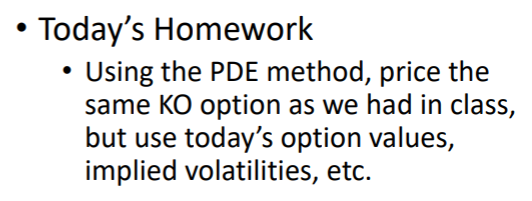
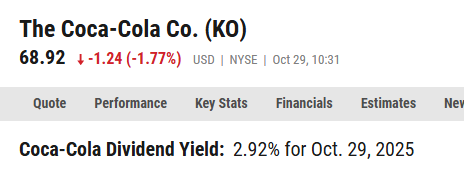

Derivative:
1. KO European Call/Put Option
2. KO American Call/Put Option

Approach:
1. Black Schole
2. Random Walk
3. Trinomial Tree
4. PDE

Assumption:
Current(2025-10-29 10:25) KO price = 70.16, set Strike Price K = 72

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
from math import prod
from scipy.stats import norm
import random
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import normal_ad
from datetime import date
from dateutil.relativedelta import relativedelta
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.linear_model import LinearRegression
import math
from datetime import date

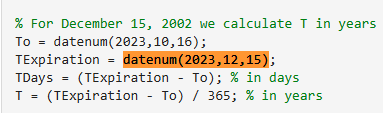
## Question: why set the expiration date in here and why using 365 instead of 252?


In [2]:
K = 72.5 #72.5 ### Strike Price
expiry = "2025-12-19" # adjust if 2025-12-15 isn't listed

n_year = 1
n_month = 12
n_day = 252

### Annualized risk free yield and dividend yield, From online
r_div_ko = 2.92/100
r_sofr = 4.24/100


### Data Preparation

In [118]:
### 1. Pull one year daily price data
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=10)
tickers = ["KO", "PEP"]

raw = yf.download(tickers, start=start, end=end, auto_adjust=False,progress=False)
prices = raw["Adj Close"].copy()
KO_current_price = prices['KO'][-1] ### Current price of KO
pep_current_price = prices['PEP'][-1] ### Current price of PEP

C:\Users\w28sh\AppData\Local\Temp\ipykernel_35524\2314456259.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  KO_current_price = prices['KO'][-1] ### Current price of KO
C:\Users\w28sh\AppData\Local\Temp\ipykernel_35524\2314456259.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pep_current_price = prices['PEP'][-1] ### Current price of PEP


In [119]:
KO_current_price

np.float64(68.9000015258789)

In [3]:
### Find a Option with market values
ticker = "KO"   # Coca-Cola
ko = yf.Ticker(ticker)
expirations = ko.options
print("Available expirations:\n", expirations)
opt_chain = ko.option_chain(expiry)

calls = opt_chain.calls
puts = opt_chain.puts

call_72 = calls[calls['strike'] == K]
put_72  = puts[puts['strike'] == K]

call_market_price = call_72['lastPrice'].values[0]
put_market_price = put_72['lastPrice'].values[0]

call_market_price, put_market_price

Available expirations:
 ('2025-11-07', '2025-11-14', '2025-11-21', '2025-11-28', '2025-12-05', '2025-12-12', '2025-12-19', '2026-01-16', '2026-02-20', '2026-03-20', '2026-05-15', '2026-06-18', '2026-09-18', '2026-12-18', '2027-01-15', '2028-01-21')


(np.float64(0.46), np.float64(4.31))

In [4]:
### 1. Pull one year daily price data
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=10)
tickers = ["KO", "PEP"]

raw = yf.download(tickers, start=start, end=end, auto_adjust=False,progress=False)
prices = raw["Adj Close"].copy()
KO_current_price = prices['KO'][-1] ### Current price of KO
pep_current_price = prices['PEP'][-1] ### Current price of PEP

C:\Users\w28sh\AppData\Local\Temp\ipykernel_35524\2314456259.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  KO_current_price = prices['KO'][-1] ### Current price of KO
C:\Users\w28sh\AppData\Local\Temp\ipykernel_35524\2314456259.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pep_current_price = prices['PEP'][-1] ### Current price of PEP


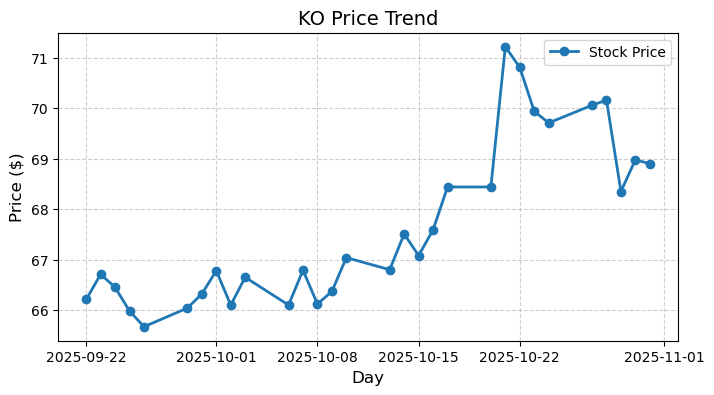

In [130]:

# Create the line chart
plt.figure(figsize=(8, 4))
plt.plot(prices.tail(30).index, prices.tail(30)['KO'], marker='o', linestyle='-', linewidth=2, label='Stock Price')

# Add titles and labels
plt.title("KO Price Trend", fontsize=14)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Show the plot
plt.show()


ko_call_implied_vol 0.21155573608398434
ko_put_implied_vol 0.188484677734375


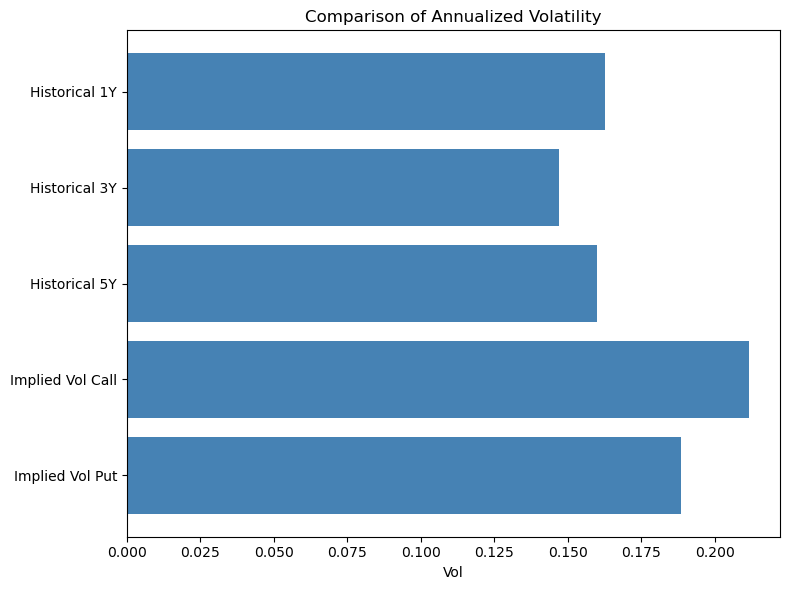

In [109]:
###3. Pull and compare the volatility. (At the money call. put, historical std)
rate_return = prices.diff()/prices
r_KO = rate_return['KO'].dropna()
### Historical vol
trading_day_year = 365#252
sigmaHist1YEAR = np.std(r_KO[-1-trading_day_year:-1]) * np.sqrt(252)
sigmaHist2YEAR = np.std(r_KO[-1-trading_day_year*2:-1]) * np.sqrt(252)
sigmaHist3YEAR = np.std(r_KO[-1-trading_day_year*3:-1]) * np.sqrt(252)


### Implied Vol
stock_nm = 'KO'
ticker = yf.Ticker(stock_nm)
spot = ticker.history(period="1d")["Close"].iloc[-1]
divs = ticker.dividends
expiries = ticker.options
first_expiration_days = '2026-09-18'
calls_df  = ticker.option_chain(first_expiration_days).calls
put_df  = ticker.option_chain(first_expiration_days).puts
strike_price_lst = calls_df['strike'].unique().tolist()
at_the_money = strike_price_lst[np.abs(strike_price_lst - spot).argmin()]
call_implied_volatility = calls_df[calls_df['strike'] == at_the_money]
put_implied_volatility = put_df[put_df['strike'] == at_the_money]

if call_implied_volatility.shape[0]>0 and \
   put_implied_volatility.shape[0]>0 and \
   call_implied_volatility['impliedVolatility'].values[0]!= 0 and \
   put_implied_volatility['impliedVolatility'].values[0]!= 0:
    ko_call_implied_vol = call_implied_volatility['impliedVolatility'].values[0]
    ko_put_implied_vol = put_implied_volatility['impliedVolatility'].values[0]
    print('ko_call_implied_vol', ko_call_implied_vol)
    print('ko_put_implied_vol', ko_put_implied_vol)

# Example data
categories = ['Historical 1Y', 'Historical 3Y',  'Historical 5Y', 'Implied Vol Call', 'Implied Vol Put']
values = [sigmaHist1YEAR, sigmaHist2YEAR, sigmaHist3YEAR,  ko_call_implied_vol , ko_put_implied_vol ]



plt.figure(figsize=(8,6))
plt.barh(categories, values, color='steelblue')
plt.title('Comparison of Annualized Volatility')
plt.xlabel('Vol')
plt.gca().invert_yaxis()  # optional: to keep top-down order same as original
plt.tight_layout()
plt.show()


### 1. Black Schole
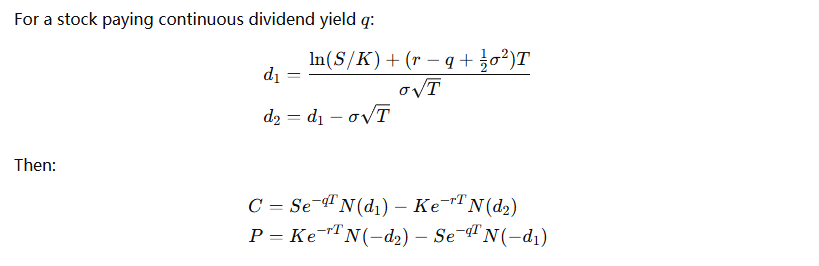

In [19]:
def black_schole(s, k, r, q, sigma_call, sigma_put, t):
    ### Call
    sigma = sigma_call
    d1 = np.log(s/k) + (r-q + 0.5* sigma**2)*t
    d2 = d1-sigma* np.sqrt(t)
    c_bs = s*np.exp(-q*t)* norm.cdf(d1) - k*np.exp(-r*t)* norm.cdf(d2)
    ### Put
    sigma = sigma_put
    d1 = np.log(s/k) + (r-q + 0.5* sigma**2)*t
    d2 = d1-sigma* np.sqrt(t)
    c_bs = s*np.exp(-q*t)* norm.cdf(d1) - k*np.exp(-r*t)* norm.cdf(d2)
    p_bs = k*np.exp(-r*t)* norm.cdf(-d2) - s*np.exp(-q*t)* norm.cdf(-d1)
    return c_bs, p_bs

In [85]:
date_today =  date.today()
expiration_date = date(int(expiry[:4]), int(expiry[5:7]), int(expiry[8:]))

T_days = (expiration_date - date_today).days      
T = T_days / n_day

bs_call, bs_put = black_schole(KO_current_price, K, r_sofr,r_div_ko,  ko_call_implied_vol , ko_put_implied_vol , T)

print('Call Option: ', bs_call)
print('Put Option: ', bs_put)

Call Option:  0.8611412817315198
Put Option:  3.890075305712429


In [86]:
bs_call_hist_vol, bs_put_hist_vol = black_schole(KO_current_price, K, r_sofr,r_div_ko,  sigmaHist1YEAR , sigmaHist1YEAR , T_days / 252)

print('Call Option: ', bs_call_hist_vol)
print('Put Option: ', bs_put_hist_vol)

Call Option:  0.5434466715054924
Put Option:  3.5723806954864017


### 2. Random Walk

In [21]:
def expected_option_price(C_RW_Expiration):
    """
    MATLAB equivalent of:
    PriceExp = Justified by the payoff of the option
    CountExp = hist(C_RW_Expiration, PriceExp);
    ProbExp = CountExp / NTrials;
    C_RW = PriceExp * ProbExp'
    """
    PriceExp = np.arange(0, max(C_RW_Expiration), 1)
    NTrials = len(C_RW_Expiration)
    CountExp, _ = np.histogram(C_RW_Expiration, bins=PriceExp)
    ProbExp = CountExp / NTrials
    C_RW = np.dot(PriceExp[:-1], ProbExp)  # match bin count length
    
    return C_RW


class simulate_random_walk:
    def __init__(self, delta_t, k, n_days, n_days_per_year, n_trail, current_price, sofr, div ,implied_vol_call, implied_vol_put):
        '''
        k = strike price
        delta_t = For each day, sliced it to delta_t steps. For example, if delta_t =5, then in one day sliced to 5 steps.
        n_trail = numbers of simulated path
        drift = risk neutral drift, sofr - dividend yield
        '''
        self.n_days = n_days  ## Total how many step
        self.n_trail = n_trail
        self.current_price = current_price
        self.k = k 
        self.sofr = sofr/(n_days_per_year)
        self.drift = (sofr - div)/(n_days_per_year)
        self.implied_vol_call = implied_vol_call/np.sqrt(n_days_per_year)
        self.implied_vol_put = implied_vol_put/np.sqrt(n_days_per_year)
        self.delta_t = delta_t

        ### Valuation of European and American call
        self.st, self.eu_call_payoff, self.euro_put_output = self.sim_call_payoff()
        self.eu_call_price = expected_option_price(self.eu_call_payoff )
        self.eu_put_price = expected_option_price(self.euro_put_output )

        

    def sim_call_payoff(self):
        implied_vol = self.implied_vol_call
        np.random.seed(42)
        step_num = int(self.n_days/self.delta_t)
        one_trail = np.random.randn(self.n_trail, step_num )
        r = pd.DataFrame(self.drift* self.delta_t + implied_vol * one_trail* np.sqrt(self.delta_t)) #this is for delta_t = 1
        #r = pd.DataFrame(self.drift + implied_vol * one_trail)
        
        r0_1 = r+1
        r1 = np.cumprod(r0_1, axis=1)
        st = self.current_price * r1
        st = st.values
        euro_output = pd.DataFrame(st).iloc[:, -1]
        
        ### European call
        euro_call_output = [max(i-self.k,0)/((1+self.sofr)**(self.n_days+1)) for i in euro_output]

        ### European Put
        euro_put_output = [max(self.k-i,0)/((1+self.sofr)**(self.n_days+1)) for i in euro_output]
            

        return st,euro_call_output, euro_put_output


In [26]:
n_trail = 10000
n_days_per_year = 252
delta_t = 1/100
r_div_ko = 0
rand_walk_eval = simulate_random_walk(delta_t,K, T_days, n_days_per_year,  n_trail, KO_current_price, r_sofr, r_div_ko ,ko_call_implied_vol, ko_put_implied_vol)
rand_walk_eval.eu_call_price, rand_walk_eval.eu_put_price

(np.float64(1.1482999999999999), np.float64(4.0188))

In [27]:
n_trail = 10000
n_days_per_year = 365
delta_t = 1/100
r_div_ko = 0
rand_walk_eval_252_historicl_var = simulate_random_walk(delta_t,K, T_days, n_days_per_year,  n_trail, KO_current_price, r_sofr, r_div_ko ,sigmaHist1YEAR, sigmaHist1YEAR)
rand_walk_eval_252_historicl_var.eu_call_price, rand_walk_eval_252_historicl_var.eu_put_price

(np.float64(0.3996), np.float64(3.3350000000000004))

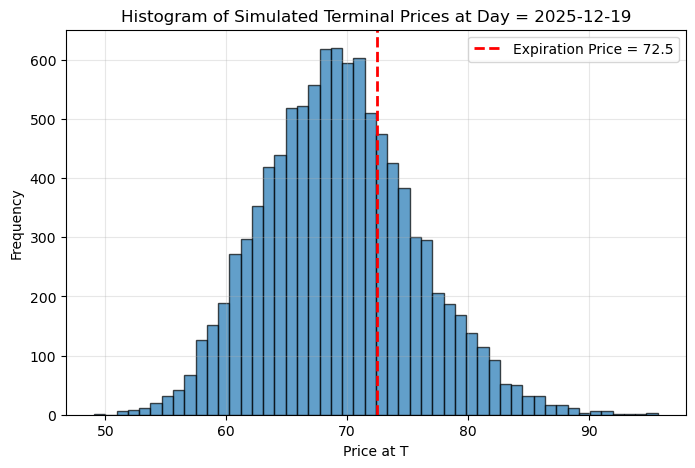

In [28]:
# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(pd.DataFrame(rand_walk_eval.st).iloc[:,-1], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(K, color='red', linestyle='--', linewidth=2, label=f'Expiration Price = {K}')

plt.title(f'Histogram of Simulated Terminal Prices at Day = {expiry}')
plt.xlabel('Price at T')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 3. PDE
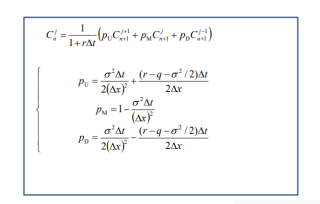
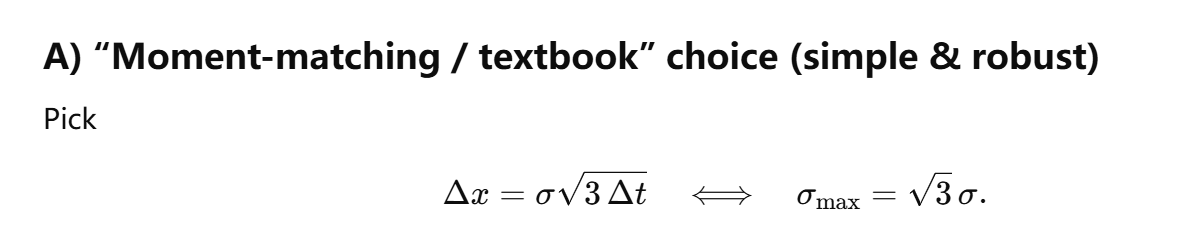

Assume the maximum standard deviation is 3 times compare with the current sd.

In [113]:
class PDE_option_valuation:
    def __init__(self, current_price,sigma_max_ratio, r_sofr, r_div, call_implied_vol, put_implied_vol, k,
                SMin, SMax, T, NT
                ):
        '''
        T: remaining time of the option, annnualized
        k = strike price
        '''
        self.So = current_price
        self.r = r_sofr
        self.b = r_sofr -r_div
        self.call_vol = call_implied_vol
        self.put_vol = put_implied_vol
        self.K = k
        self.SMin = SMin
        self.SMax = SMax
        self.sigma_max_ratio = sigma_max_ratio
        
        ### Set delta_t first (same for call and put)
        self.TMin = 0
        self.TMax = T ### in annualized 
        self.NT = NT
        

        self.dT = (self.TMax - self.TMin) / self.NT
        self.TGridPDE = np.linspace(self.TMin, self.TMax, self.NT) 

        self.XMin = np.log(self.SMin/self.So)
        self.XMax = np.log(self.SMax/self.So)

        #### Call option set up and pricing
        self.call_IntrinsicVPDE, self.call_VPDE,self.SGridPDE_call,self.call_NX , self.call_p_u, self.call_p_m, self.call_p_d = self.create_call_grid()
        self.call_price_american, self.call_price_eur, self.call_VPDE_eur_output,self.call_VPDE_output  = self.call_option_valuation()
        
        #### Put option set up 
        self.put_IntrinsicVPDE, self.put_VPDE, self.SGridPDE_put, self.put_NX, self.put_p_u, self.put_p_m, self.put_p_d = self.create_put_grid()
        self.put_price_american, self.put_price_eur,self.put_VPDE_eur_output,self.put_VPDE_output =  self.put_option_valuation()

        
        
    def create_call_grid(self):        
        ### Set grid for call, since intrinsic value for call/put are different
        mu = self.b - self.call_vol**2/2
        sigma_max = self.call_vol * np.sqrt(self.sigma_max_ratio )
        check_threhold = (sigma_max/mu)**2
        if self.dT < check_threhold:
            print('Call option Pass the non expansion condition, no need to adjust delta_t')
        else:
            print('Call option Not Pass the non expansion condition, need change delta_t')
            print(self.dT , check_threhold)
            
        NX = round( (self.XMax - self.XMin) /(sigma_max* np.sqrt(self.dT)))
        dX = (self.XMax - self.XMin) / NX

         
        XGridPDE = np.linspace(self.XMin, self.XMax, NX)
        dX = (self.XMax - self.XMin) / NX ## refresh dX becayse if the rounding
        SGridPDE = self.So * np.exp(XGridPDE) ### Grid in price, take 300 steps

        
        IntrinsicVPDE = [max(i - self.K, 0) for i in SGridPDE] 
        VPDE = np.full((NX, self.NT), np.nan)
        VPDE[:, -1] = IntrinsicVPDE
        VPDE[0, :] = IntrinsicVPDE[0]
        VPDE[-1, :] = IntrinsicVPDE[-1]
        
        ### upper/lower/median for call
        p_u = (self.call_vol**2 * self.dT) / (2 * dX**2) + (self.b - self.call_vol**2/2) * self.dT / (2*dX)
        p_m = 1 - self.call_vol**2 * self.dT / (dX**2)
        p_d = (self.call_vol**2 * self.dT) / (2 * dX**2) - (self.b - self.call_vol**2/2) * self.dT / (2*dX)

        return IntrinsicVPDE, VPDE, SGridPDE, NX, p_u, p_m, p_d

    
    def create_put_grid(self):        
        mu = self.b - self.put_vol**2/2
        sigma_max = self.put_vol * np.sqrt(self.sigma_max_ratio )
        ### Set grid for call, since intrinsic value for call/put are different
        NX = round( (self.XMax - self.XMin) /(sigma_max* np.sqrt(self.dT)))
        dX = (self.XMax - self.XMin) / NX

        check_threhold = (sigma_max/mu)**2
        if self.dT < check_threhold:
            print('Put option Pass the non expansion condition, no need to adjust delta_t')
        else:
            print('Put option Not Pass the non expansion condition, need change delta_t')
            print(self.dT , check_threhold)
            
        XGridPDE = np.linspace(self.XMin, self.XMax, NX)
        dX = (self.XMax - self.XMin) / NX ## refresh dX becayse if the rounding
        SGridPDE = self.So * np.exp(XGridPDE) ### Grid in price, take 300 steps

        
        IntrinsicVPDE = [max( self.K-i, 0) for i in SGridPDE] 
        VPDE = np.full((NX, self.NT), np.nan)
        VPDE[:, -1] = IntrinsicVPDE
        VPDE[0, :] = IntrinsicVPDE[0]
        VPDE[-1, :] = IntrinsicVPDE[-1]
        
        ### upper/lower/median for call
        p_u = (self.put_vol**2 * self.dT) / (2 * dX**2) + (self.b - self.put_vol**2/2) * self.dT / (2*dX)
        p_m = 1 - self.put_vol**2 * self.dT / (dX**2)
        p_d = (self.put_vol**2 * self.dT) / (2 * dX**2) - (self.b - self.put_vol**2/2) * self.dT / (2*dX)
        

        return IntrinsicVPDE, VPDE,SGridPDE, NX, p_u, p_m, p_d

    def call_option_valuation(self):
        VPDE = self.call_VPDE
        IntrinsicVPDE = self.call_IntrinsicVPDE
        p_u = self.call_p_u
        p_m = self.call_p_m
        p_d = self.call_p_d
        NX = self.call_NX
        
        VPDE_eur = VPDE.copy()
        for n in range(NT-2, -1, -1):  ## Logic difference in matlab and python
            for j in range(1, NX-1): 
                cont = (p_u * VPDE[j+1, n+1] + p_m * VPDE[j, n+1] + p_d * VPDE[j-1, n+1]) / (1 + self.r * self.dT)
                ### European
                VPDE_eur[j,n] = cont
                ### Americam
                VPDE[j, n] = max(IntrinsicVPDE[j], cont)
                #if cont<IntrinsicVPDE[j]:
                #    print(1)
                    
        ICurrentPrice = np.argmax(self.SGridPDE_call >= self.So)
        call_price_american = VPDE[ICurrentPrice, 0]
        call_price_eur = VPDE_eur[ICurrentPrice, 0]
        
        return call_price_american, call_price_eur,VPDE_eur, VPDE

    def put_option_valuation(self):

        VPDE = self.put_VPDE
        IntrinsicVPDE = self.put_IntrinsicVPDE
        p_u = self.put_p_d #self.put_p_u
        p_m = self.put_p_m
        p_d = self.put_p_u #self.put_p_d
        NX = self.put_NX

        print(p_u, p_m, p_d)
        VPDE_eur = VPDE.copy()
        for n in range(NT-2, -1, -1):  ## Logic difference in matlab and python
            for j in range(1, NX-1): 
                cont = (p_u * VPDE[j+1, n+1] + p_m * VPDE[j, n+1] + p_d * VPDE[j-1, n+1]) / (1 + self.r * self.dT)
                ### European
                VPDE_eur[j,n] = cont
                ### Americam
                VPDE[j, n] = max(IntrinsicVPDE[j], cont)
                #if cont<IntrinsicVPDE[j]:
                #    print(1)
                    
        ICurrentPrice = np.argmax(self.SGridPDE_put >= self.So)
        put_price_american = VPDE[ICurrentPrice, 0]
        put_price_eur = VPDE_eur[ICurrentPrice, 0]
        
        return put_price_american, put_price_eur, VPDE_eur, VPDE
    

In [114]:
SMin = 44
SMax = 105
NT = 5000
sigma_max_ratio = 2
PDE_pricing = PDE_option_valuation( KO_current_price,sigma_max_ratio,  r_sofr, r_div_ko, ko_call_implied_vol, ko_put_implied_vol, K,
                SMin, SMax, T, NT
                )

call_eur_PDE = PDE_pricing.call_price_eur,
call_american_PDE = PDE_pricing.call_price_american
put_eur_PDE = PDE_pricing.put_price_eur
put_american_PDE = PDE_pricing.put_price_american

call_eur_PDE,put_eur_PDE

Call option Pass the non expansion condition, no need to adjust delta_t
Put option Pass the non expansion condition, no need to adjust delta_t
0.2494775945466696 0.500480592258232 0.2500418131950983


((np.float64(1.3389268167936468),), np.float64(4.547164030320486))

In [55]:
SMin = 44
SMax = 105
NT = 5000
sigma_max_ratio = 2
PDE_pricing_365_hist_var = PDE_option_valuation( KO_current_price,sigma_max_ratio,  r_sofr, r_div_ko, sigmaHist1YEAR, sigmaHist1YEAR, K,
                SMin, SMax, T*252/365, NT
                )

call_eur_PDE_365_hist_var = PDE_pricing_365_hist_var.call_price_eur,
call_american_PDE_365_hist_var = PDE_pricing_365_hist_var.call_price_american
put_eur_PDE_365_hist_var = PDE_pricing_365_hist_var.put_price_eur
put_american_PDE_365_hist_var = PDE_pricing_365_hist_var.put_price_american

call_eur_PDE_365_hist_var,put_eur_PDE_365_hist_var

Call option Pass the non expansion condition, no need to adjust delta_t
Put option Pass the non expansion condition, no need to adjust delta_t
0.24946664779141914 0.5004230238290848 0.2501103283794961


((np.float64(0.5212242069458144),), np.float64(4.103013133701165))

### Summary

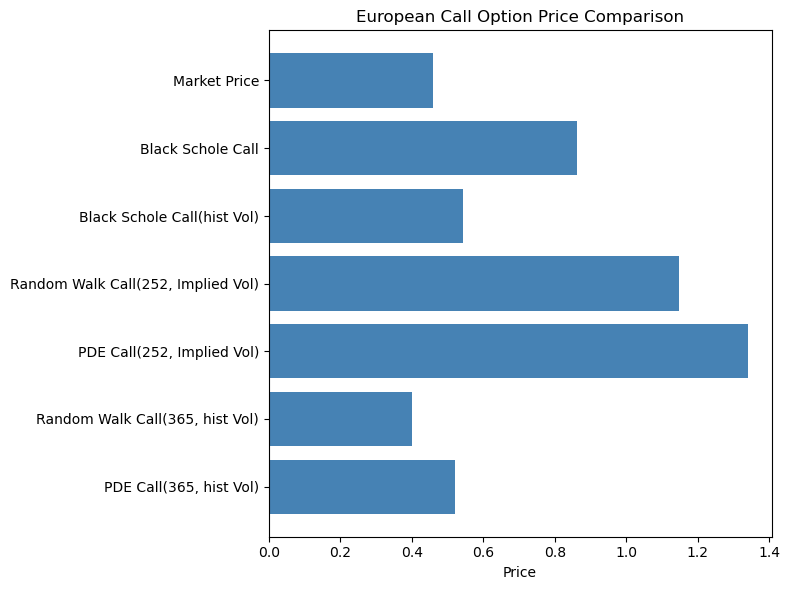

In [107]:
# Example data
labels = ['Market Price',
              'Black Schole Call', 
              'Black Schole Call(hist Vol)', 
              'Random Walk Call(252, Implied Vol)', 
              'PDE Call(252, Implied Vol)',
              'Random Walk Call(365, hist Vol)',
              'PDE Call(365, hist Vol)',
             ]
values = [call_72['lastPrice'].values[0],
          bs_call, 
          bs_call_hist_vol, 
          rand_walk_eval.eu_call_price,
         call_eur_PDE[0], 
         rand_walk_eval_252_historicl_var.eu_call_price,
          call_eur_PDE_365_hist_var[0],
         ]

plt.figure(figsize=(8,6))
plt.barh(labels, values, color='steelblue')
plt.title('European Call Option Price Comparison')
plt.xlabel('Price')
plt.gca().invert_yaxis()  # optional: to keep top-down order same as original
plt.tight_layout()
plt.show()


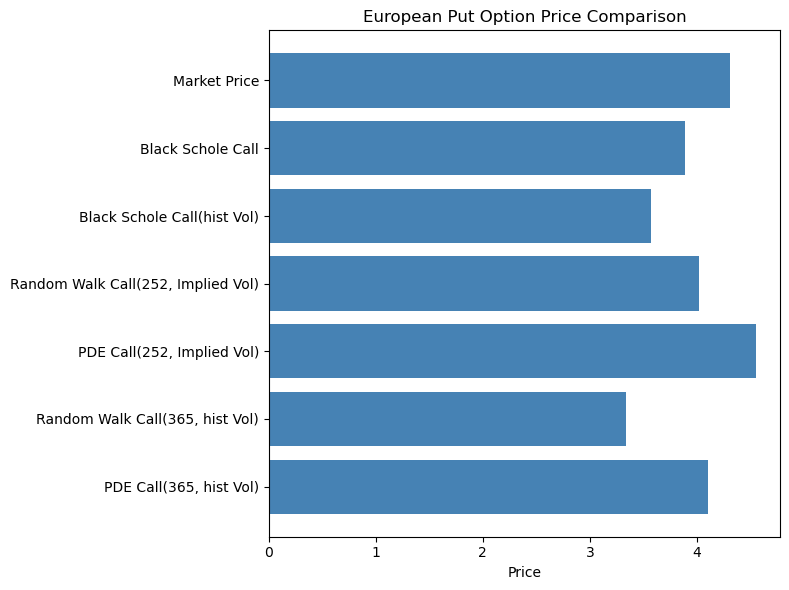

In [106]:
# Example data
categories = ['Market Price',
            'Black Schole Put', 
              'Black Schole Put (Hist Vol)',
              'Random Walk Put', 
             'PDE Put',
                'Random Walk Put (365, hist Vol)',
              'PDE Euro Put (365, hist Vol)',
             ]
values = [put_72['lastPrice'].values[0],
          bs_put, 
          bs_put_hist_vol, 
         rand_walk_eval.eu_put_price, 
         put_eur_PDE, 
         rand_walk_eval_252_historicl_var.eu_put_price,
          put_eur_PDE_365_hist_var
         ]

plt.figure(figsize=(8,6))
plt.barh(labels, values, color='steelblue')
plt.title('European Put Option Price Comparison')
plt.xlabel('Price')
plt.gca().invert_yaxis()  # optional: to keep top-down order same as original
plt.tight_layout()
plt.show()
